# Simulazione II


## Esercizio 1

Si condiderino i due sistemi lineari:

     A  x = b 

    A1 x1 = b1

dove A, A1 sono le matrici dei coefficienti, b e b1 sono i termini noti, ed x ed x1 sono i vettori incongiti da determinare.
I dati di questi due sistemi lineari sono contenuti nel file **testI.mat**.


- Si implementino almeno due metodi che sono adatti a risolvere sistemi lineari con le caratteristiche delle matrici dei coefficienti date in input.
                                      **punti 6**
- Sperimentazione:

    -  Per ognuno dei due sistemi lineari, usare i metodi implementati per calcolarne la soluzione, confrontare il numero di iterazioni e confrontare su grafico l'andamento dell'errore ad ogni iterazione. 

    - Per ciascun metodo implementato, si studi il comportamento dell’algoritmo al variare delle matrici in esame. Si rappresenti graficamente l’andamento dell’errore in funzione del numero di iterazioni e si confrontino i risultati ottenuti, mettendo in evidenza il ruolo dell’indice di condizionamento nella velocità di convergenza. Si forniscano infine adeguate giustificazioni teoriche dei fenomeni osservati.
                                      **punti 4**

Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('testI')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``

``A1=dati["A1"] ``

``A1=A1.astype(float)``

`` b1=dati["b1"] ``

`` b1=b1.astype(float)``


- Dato il sistema lineare Ax= b, con  matrice dei coefficienti
$$
A= \left[
\begin{array}{cccc}
3.0 &2.0 & 1.0 & -1.0\\
2.0 & 6.0 & 1.0 & 4.0\\
1.0 & 1.0 & 4.0 & 3.0\\
-1.0 & 4.0 & 3.0 & 7.0
\end{array}
\right ],$$
e termine noto b tale per cui la soluzione del sistema lineare sia il vettore formato da tutti 1,

- dire se  è possibile applicare il metodo di fattorizzazione di Cholesky richiamando il Teorema di Cholesky e verificare sperimentalmente le ipotesi di applicabilità. Risolvere il sistema lineare utilizzando la fattorizzazione di Cholesky se è possibile, altrimenti ricorrere ad un altro meodo di fattorizzazione, spiegandone le motivazioni.
 **[punti 2]**

Informazioni matrice  A
Dimensioni:  (600, 600)
Simmetrica?  True
Definita positiva?  True
Condizionamento:  9.999999999999664
Rango:  600
Informazioni matrice  A1
Dimensioni:  (600, 600)
Simmetrica?  True
Definita positiva?  True
Condizionamento:  1000.0000000000176
Rango:  600
raggio spettrale Gauss-Seidel  0.5799231134812625


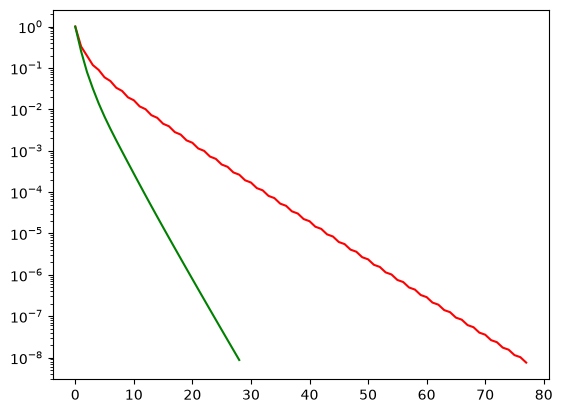

raggio spettrale Gauss-Seidel  0.9903091028488544


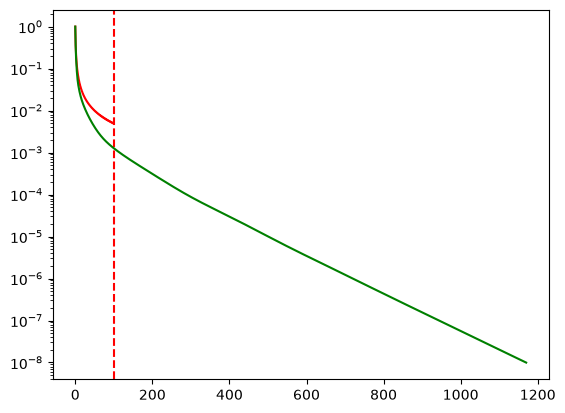

In [72]:
from scipy.io import loadmat
import numpy as np
import SolveTriangular as st
import matplotlib.pyplot as plt 

dati = loadmat('test1')
A=dati["A"] 
A=A.astype(float)
b=dati["b"] 
b=b.astype(float)
A1=dati["A1"] 
A1=A1.astype(float)
b1=dati["b1"] 
b1=b1.astype(float)

def matrix_checks(mat: np.matrix, name):
    print("Informazioni matrice ", name)
    print("Dimensioni: ", mat.shape)
    print("Simmetrica? ", np.allclose(mat, mat.T))
    print("Definita positiva? ", np.all(np.linalg.eigvals(mat) > 0))
    print("Condizionamento: ", np.linalg.cond(mat))
    print("Rango: ", np.linalg.matrix_rank(mat))

matrix_checks(A, "A") # La matrice risulta quadrata, grande, e simmetrica positiva, userò quindi gauss seidel e steepest descent

def gauss_seidel(A,b,x0,toll,it_max):   # Definisce la funzione che implementa il metodo iterativo di Gauss-Seidel

    errore=1+toll                      # Inizializza l'errore con un valore maggiore di toll per entrare nel ciclo

    d= np.diag(A) #to do   
    D= np.diag(d) #to do  

    E= np.tril(A, -1) #to do   
    F= np.triu(A, 1) #to do  

    M= D + E#to do  
    N= -F #to do  
    
    T= np.linalg.inv(M) @ N #to do                             # Costruisce la matrice di iterazione di Gauss-Seidel

    autovalori=np.linalg.eigvals(T)     # Calcola gli autovalori della matrice di iterazione
    raggiospettrale= np.max(np.abs(autovalori)) #to do  # Calcola il raggio spettrale 

    print("raggio spettrale Gauss-Seidel ",raggiospettrale) # Stampa il raggio spettrale

    it=0                                # Inizializza il contatore delle iterazioni

    er_vet=[]                           # Lista per salvare l'errore a ogni iterazione

    while errore > toll and it < it_max: #to do  
        x, _ = st.Lsolve(M, b + N @ x0 ) #to do 

        errore= np.linalg.norm(x - x0) / np.linalg.norm(x) # to do Calcola l'errore relativo tra due iterazioni successive

        er_vet.append(errore)           # Salva l'errore corrente

        x0=x.copy()                     # Aggiorna la soluzione per l'iterazione successiva

        it=it+1                         # Incrementa il contatore delle iterazioni

    return x,it,er_vet                  # Restituisce: soluzione approssimata, numero iterazioni, vettore errori

def steepestdescent(A, b, x0, itmax, tol):
    # A = matrice del sistema
    # b = termine noto
    # x0 = punto iniziale
    # itmax = numero massimo di iterazioni
    # tol = tolleranza per il criterio di arresto

    n, m = A.shape  # dimensioni della matrice A
    if n != m:
        print("Matrice non quadrata")
        return [], []  # il metodo richiede una matrice quadrata

    # inizializzazione
    x = x0  # soluzione iniziale

    r = A @ x - b #to do    
    p = -r #to do  
    it = 0              # contatore iterazioni

    nb = np.linalg.norm(b)         
    errore = np.linalg.norm(r) / nb#to do                         # errore relativo iniziale

    vec_sol = []            # lista delle soluzioni iterate
    vec_sol.append(x.copy())

    vet_r = []              # lista degli errori
    vet_r.append(errore)

    # ciclo del metodo del gradiente
    while errore >= tol and it < itmax:
        it = it + 1  # incremento iterazioni

        Ap= A @ p#to do  
        # calcolo del passo ottimo (minimizza lungo la direzione p)
        alpha = -(r.T @ p) / (p.T @ Ap) #to do  

        # aggiornamento soluzione
        x= x + alpha * p #to do  

        # salva iterata
        vec_sol.append(x.copy())

        # aggiornamento residuo (più efficiente che ricalcolare A@x - b)
        r = r + alpha * Ap #to do  

        # aggiornamento errore
        errore = np.linalg.norm(r) / nb #to do  
        vet_r.append(errore)

        # nuova direzione  
        p = -r #to do  

    # costruzione matrice delle iterate (ogni riga = una iterazione)
    iterates_array = np.array(vec_sol)

    # output
    return x, vet_r, iterates_array, it

matrix_checks(A1, "A1") # Analogo alla matrice A solo che è molto mal condizionata, comporterà un errore molto più alto

x, vet_r, it_vet, it = steepestdescent(A, b, np.zeros(A.shape[0]).reshape(A.shape[0], 1), 100, 1e-8)
plt.semilogy(np.arange(it + 1), vet_r, "r") 
# Si nota come la matrice converga in circa 80 iterazioni, questo perché è abbastanza ben condizionata

x, it, er_vet = gauss_seidel(A, b, np.zeros(A.shape[0]).reshape(A.shape[0], 1), 1e-8, 100)
plt.semilogy(np.arange(it), er_vet, "g") 

plt.show() # stampo la matrice A1

x2, vet_r2, it_vet2, it2 = steepestdescent(A1, b1, np.zeros(A1.shape[0]).reshape(A1.shape[0], 1), 100, 1e-8)
plt.semilogy(np.arange(it2 + 1), vet_r2, "r") 

plt.axvline(100, linestyle="--", color="red") # 100° iterazione, quando steepest si blocca

# La seconda matrice non riesce a convergere nelle 100 iterazioni, questo perché è altamente mal condizionata
# Aumento quindi le iterazioni a 1200.

x1, it1, er_vet1 = gauss_seidel(A1, b1, np.zeros(A1.shape[0]).reshape(A1.shape[0], 1), 1e-8, 1200)
plt.semilogy(np.arange(it1), er_vet1, "g")

# Dai due grafici si evince come la funzione usata sulla matrice A essendo ben condizionata abbia impiegato soltanto 80 iterazioni
# per convergere, mentre la funzione sulla matrice A1 essendo mal condizionata ha impiegato ben 1200 iterazioni. 
# per la teoria dei metodi iterativi, ad un condizionamento alto equivale un minor passo ad ogni iterazione,
# per questo la matrice A1 impiega molto di più della matrice A.
# Si noti inoltre come Gauss-Seidel sia più rapito di Steepest Descent.

## Esercizio 2

Si consideri il polinomio $$f(x)=x^4-13 \cdot x^3 + 62 \cdot x^2 - 128 \cdot x + 96.0 $$ 


Si visualizzi il grafico del polinomio in [1.7,4.6] 

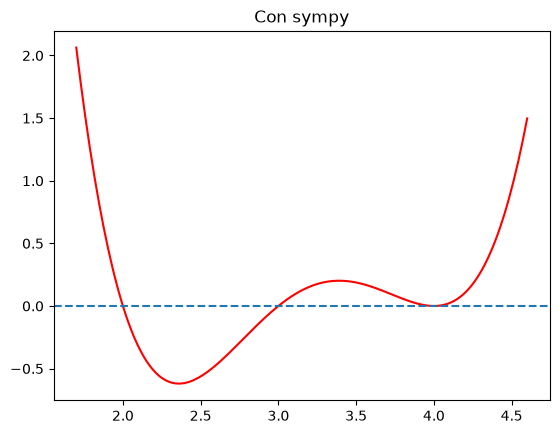

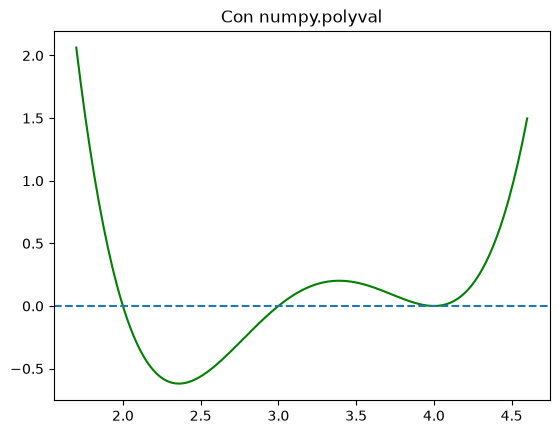

In [73]:
import sympy as sym

x_axis = np.linspace(1.7, 4.6, 200) # intervallo [1.7, 4.6]

# Metodo con sympy
x = sym.symbols("x")
fx = x ** 4 - 13.0 * x ** 3 + 62.0 * x**2 - 128.0 * x + 96.0
fx_numpy = sym.lambdify(x, fx, np)

# Metodo con np.polyval
coefficienti = [1, -13, 62, -128, 96]
fxpoly = lambda x: np.polyval(coefficienti, x_axis)

plt.title("Con sympy")
plt.plot(x_axis, fx_numpy(x_axis), 'r')
plt.axhline(0, linestyle="--")
plt.show() # per visualizzare meglio che si sovrappongono
plt.title("Con numpy.polyval")
plt.plot(x_axis, fxpoly(x_axis), 'g')

plt.axhline(0, linestyle="--")

- Si implementi il metodo di Newton per la determinazione degli zeri di un'equazione non lineare [**Punti 3**]

In [74]:
def newton(fname,fpname,x0,tolx,tolf,nmax):
    
     # fpname è la lambda function contenente la derivata prima di fname
        v_xk=[]
        xk=x0
        
        it=0
        xk1=None
        errorex=1+tolx
        erroref=1+tolf
        while errorex > tolx and erroref > tolf and it < nmax: #to do  :
           
           fxk=fname(xk)
           fpxk=fpname(xk)
           if abs(fpxk) <= np.spacing(1): #to do 
             print("Newton: La derivata prima si annulla ")
             return None,None,None
        
           d= fxk / fpxk #to do
                    
           '''
           #xk1= ascissa del punto di intersezione tra  la retta che passa per il punto
           (xk,f(xk)) e ha pendenza uguale a quella della tangente nel punto  e l'asse x
           '''
           xk1= xk - d #to do
           
           fxk1=fname(xk1)
           
           if xk1!=0:
                errorex= abs(d) / abs(xk1) #to do
           else:
                errorex= abs(d)#to do 
           
           erroref=np.abs(fxk1)

           v_xk.append(xk1)
 
           xk=xk1
           it=it+1
          
        if it==nmax:
            print('Newton : raggiunto massimo numero di iterazioni \n')
            
        
        return xk1,it,np.array(v_xk)

- Si implementi il metodo della regula falsi (falsa posizione)  per la determinazione degli zeri di un'equazione non lineare [**Punti 3**]

In [83]:
def falsi(fname, a, b, maxit, tolx,tolf):
 """
 Implementa il metodo di falsa posizione per il calcolo degli zeri di un'equazione non lineare.

 Parametri:
  f: La funzione da cui si vuole calcolare lo zero.
  a: L'estremo sinistro dell'intervallo di ricerca.
  b: L'estremo destro dell'intervallo di ricerca.
  tol: La tolleranza di errore.

 Restituisce:
  Lo zero approssimato della funzione, il numero di iterazioni e la lista di valori intermedi.
 """
 fa=fname(a)
 fb=fname(b)
 if np.sign(fa) * np.sign(fb) >= 0: #to do
     print("Non è possibile applicare il metodo di falsa posizione \n")
     return None, None,None

 it = 0
 v_xk = []
 
 fxk=tolf+1

 errore=tolx+1
 xk=None
 xprec=a
 
 while errore > tolx and np.abs(fxk) > tolf and it < maxit: #to do 
        xk = a - fa * (b - a) / (fb - fa) #to do 
         
        fxk=fname(xk)
        if np.abs(fxk)<tolf:
          return xk, it, np.array(v_xk)
    
        if np.sign(fxk) * np.sign(fa) < 0: #  #la radice si trova nell'intervallo [a, xk].
          b = xk
          fb=fxk
        elif np.sign(fxk) * np.sign(fb) < 0: #to do   #la radice si trova nell'intervallo [xk, b].
          a = xk
          fa=fxk
    
        if xk!=0:
             errore= abs(xk - xprec) / xk# to do
        else:
             errore= abs(xk - xprec)#to do
        
        xprec=xk
        v_xk.append(xk)
        it += 1
 return xk, it, np.array(v_xk)


- Si utilizzi il metodo di Newton per individuare tutti gli zeri  del polinomio, (scegliendo opportunamente l'iterato iniziale per il calcolo di ciascuna di esse) e calcolare l'ordine del metodo per il calcolo di ciascuno zero. Dare la definizione teorica di ordine di convergenza e giustificare i risultati alla luce della teoria. [**Punti 4**]

In [ ]:
import sympy as sym

def stima_ordine(xk,iterazioni):
     #Vedi dispensa allegata per la spiegazione

      k=iterazioni-4
      p=np.log(abs(xk[k+2]-xk[k+3])/abs(xk[k+1]-xk[k+2]))/np.log(abs(xk[k+1]-xk[k+2])/abs(xk[k]-xk[k+1]));
     
      ordine=p
      return ordine

derivata_prima = sym.diff(fx, x, 1) # Derivazione in x di ordine 1 (derivata 1°)
fdx_numpy = sym.lambdify(x, derivata_prima, np)

sol, it, err = newton(fname=fx_numpy, fpname=fdx_numpy, x0 = np.min(x_axis), tolx = 1e-8, tolf = 1e-8, nmax = 100)
print("Soluzione trovata:", sol)
print("Ordine: ", stima_ordine(err, it))

Soluzione trovata: 1.9999999999996614
Ordine:  2.004874118203259


- Si consideri la funzione $g(x)=f(x)/((x-x_1^*)(x-x_2^*))$ dove $x_1^*$ ed $x_2^*$ sono  gli zeri del polinomio di ascissa più piccola e più grande, rispettivamente, tra quelli calcolati al punto precedente. 
Visualizzare i grafici di g(x) e f(x) e dire se i due polinomi hanno degli zeri in comune. 
Calcolare con il metodo di Newton gli zeri di $g(x)$ [**Punti 1**]

Zeri in comune:  3.000000000000001 ,  3.9999999433231075


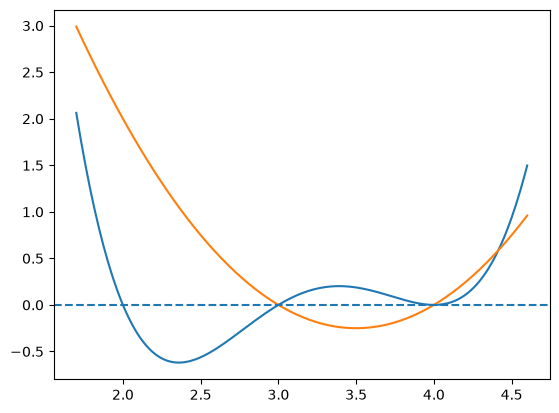

In [93]:
x1star, _, _ = newton(fname=fx_numpy, fpname=fdx_numpy, x0 = np.min(x_axis), tolx = 1e-12, tolf = 1e-12, nmax = 100)
x2star, _, _ = newton(fname=fx_numpy, fpname=fdx_numpy, x0 = np.max(x_axis), tolx = 1e-12, tolf = 1e-12, nmax = 100)

gx = fx / ((x - x1star) * (x - x2star))
gx_numpy = sym.lambdify(x, gx, np)
plt.plot(x_axis, fx_numpy(x_axis))
plt.plot(x_axis, gx_numpy(x_axis))
plt.axhline(0, linestyle="--") # linea dello 0

zero_comune1, _, _ = newton(gx_numpy, sym.lambdify(x, sym.diff(gx, x, 1), np), 2.9, 1e-12, 1e-12, 100)
zero_comune2, _, _ = newton(gx_numpy, sym.lambdify(x, sym.diff(gx, x, 1), np), 3.5, 1e-12, 1e-12, 100)
print("Zeri in comune: ", zero_comune1, ", ", zero_comune2)

- Si applichi il metodo della regula falsi alle funzioni $f(x)$ e $g(x)$ nell'intervallo  [1.7,4.6] e si fornisca una spiegazione teorica dei risultati ottenuti. Si indichi  un intervallo di studio opportuno affinchè con il metodo di falsa posizione sia possibile calcolare la radice con ascissa maggiore della funzione g(x) e verificare sperimentalmente che porta a soluzione  [**Punti 2**]

In [89]:
fsol, fit, ferrvet = falsi(fx_numpy, 1.7, 4.6, 100, 1e-8, 1e-8)
gsol, git, gerrvet = falsi(gx_numpy, 1.7, 4.6, 100, 1e-8, 1e-8)

# Non è possibile applicare il metodo di falsa posizione per via del teorema dei segni, in quanto i due estremi sono concordi di segno.

# L'intervallo opportuno per trovare la radice con ascissa maggiore in g(x) è 3.9 4.1
gsol, git, gerrvet = falsi(gx_numpy, 3.9, 4.1, 100, 1e-8, 1e-8)
print(f"Soluzione {gsol} in {git} iterazioni.")


Non è possibile applicare il metodo di falsa posizione 

Non è possibile applicare il metodo di falsa posizione 

Soluzione 3.999998278307784 in 48 iterazioni.


# Domande IA

**1.**  Quali di queste affermazioni sono vere: 

(a) La procedura di “annotazione” consiste nell’ottenere, per un certo dato di input, l’etichetta predetta da un dato modello 

--> (b)  I dati annotati sono necessari in un contesto di learning supervisionato 

--> (c) Non tutti gli algoritmi di Machine Learning necessitano di dati annotati 

(d) In un problema di apprendimento automatico il cui scopo è la predizione dell’altezza di una persona, l’età è un’etichetta utile 

**2.** Quali di queste affermazioni sono vere: 

(a)  Non esistono reti che prevedono connessioni all'indietro, ma esistono reti che prevedono biforcazioni 

--> (b) Al fine di apprendere relazioni complesse, le funzioni di attivazione devono essere sia derivabili che non-lineari 

--> (c) L’obiettivo del processo di apprendimento dei pesi di una rete neurale è quello di minimizzare la funzione obiettivo, ovvero a minimizzare la funzione di costo. 

--> (d) Il Multilayer Perceptron (MLP) prevede la presenza di layer “hidden” 


**3.**  Quali di queste affermazioni sono vere: 

--> (a)  In una rete Multilayer Perceptron l’immagine viene appiattita e non si tiene conto della sua struttura bidimensionale 

--> (b)  In un layer di convoluzione, la convoluzione è applicata a un’immagine con un meccanismo di sliding window 

(c)  In una rete Convolutional Neural Network (CNN) è ammessa la presenza esclusivamente di layer di convoluzione (sia 2D che 3D), layer di pooling ed eventualmente di normalizzazione e dropout 

(d)  Se un’immagine di input ha 3 canali e viene passata in input a un layer di convoluzione che prevede 10 kernel, l’output di tale layer sarà un tensore di 30 canali 3- Quale delle seguenti affermazioni è vera riguardo ai layer convoluzionali in una rete CNN?


**4.**  Quali di queste affermazioni sono vere: 

Il dataset di validazione 

--> (a)  Può essere usato per tarare gli iperparametri del modello 

--> (b)  Può essere usato per verificare una discrepanza rispetto all'accuratezza ottenuta sul training set 

(c)  La sua dimensione dovrebbe essere simile a quella del training set 

--> (d)  Il suo contenuto deve essere completamente disgiunto da quello del test set 

**5.**  Quale delle seguenti affermazioni è la definizione CORRETTA di learning rate nel training di una rete neurale?

(a) Il numero di volte in cui l'intero set di dati viene utilizzato durante il training.

--> (b) Un parametro che controlla la velocità con cui i pesi della rete vengono aggiornati durante il training.

(c) Il numero di neuroni presenti nello strato di output della rete.

(d) La funzione di attivazione utilizzata dai neuroni della rete 

# Domande aperte

**6. Si descrivano le fasi di forward-propagation e back-propagation nel contesto dell'addestramento di una rete neurale**.   [punti 1.5]

L'addestramento di una rete neurale avviene attraverso il ciclo continuo di due fasi:

Forward Propagation (Propagazione in avanti): È il percorso dall'input all'output. I dati di ingresso passano attraverso i vari strati della rete, dove ogni neurone elabora le informazioni moltiplicandole per i propri pesi e applicando una funzione di attivazione non lineare. Alla fine della rete si ottiene una predizione, che viene confrontata con il risultato reale per calcolare l'errore commesso (tramite la funzione di costo).

Backpropagation (Retropropagazione): È il percorso inverso, dall'output all'input. L'errore calcolato viene fatto scorrere all'indietro lungo la rete per capire quanto ogni singolo peso abbia contribuito a quell'errore (usando la regola della catena delle derivate). Infine, un algoritmo di ottimizzazione usa queste informazioni e il learning rate per modificare i pesi della rete, riducendo l'errore per i calcoli successivi.

**7. Descrivere il Gradient Descent con Momentum, spiegando il ruolo del termine di velocità, il significato del
parametro di momentum e in che modo questo metodo permette di ridurre le oscillazioni e accelerare la
convergenza rispetto al Gradient Descent classico**[punti 3]

Il Gradient Descent con Momentum è un'estensione del Gradient Descent (GD) classico che simula il comportamento di una sfera che rotola lungo la funzione di costo, accumulando inerzia per accelerare la convergenza e superare i punti critici.Ruolo del termine di velocità: Rappresenta la direzione e la forza dei movimenti precedenti (una media dei gradienti passati). Se i gradienti puntano coerentemente nella stessa direzione, la velocità aumenta, consentendo di fare passi più lunghi ed attraversare rapidamente anche le zone piatte.Significato del parametro di momentum ($\beta$): È un valore compreso tra 0 e 1 che controlla il "fattore di inerzia", cioè quanta della velocità passata mantenere al passo attuale (tipicamente impostato a $0.9$).Riduzione delle oscillazioni e accelerazione: Nelle zone in cui il GD classico oscillerebbe rimbalzando tra le pareti di un "vallone", il Momentum cancella le componenti opposte dell'errore (che si annullano a vicenda) e somma quelle nella direzione del minimo. In questo modo smorza le oscillazioni inutili e spinge il modello più velocemente verso la soluzione.